# **SMS-Spam Classification**

---

## **Table of Contents**

- [Environment Setup (Local or Google Colab)](#environment-setup-local-or-google-colab)
- [Introduction](#introduction)
- [Datasets Preparation (Balanced)](#datasets-preparation-balanced)
  - [Download and Split Datasets](#download-and-split-datasets)
  - [Create Data Loaders](#create-data-loaders)
- [Model Setup](#model-setup)
  - [Initialize a Local GPT-2 Model and Load Weights From OpenAI](#initialize-a-local-gpt-2-model-and-load-weights-from-openai)
  - [Verify The Loaded Model](#verify-the-loaded-model)
  - [Classification Head Adaptation & Fine-Tuning Strategy](#classification-head-adaptation--fine-tuning-strategy)
  - [Sanity Check: Output Shape & Logit Verification](#sanity-check-output-shape--logit-verification)
- [Finetuning The Model](#finetuning-the-model)
  - [Pre-Fine-Tuning Baseline Evaluation](#pre-fine-tuning-baseline-evaluation)
  - [Fine-Tuning Execution & Optimizer Setup](#fine-tuning-execution--optimizer-setup)
  - [Visualization of Training Dynamics](#visualization-of-training-dynamics)
- [Final Metric Evaluation Across Datasets](#final-metric-evaluation-across-datasets)
- [Inference: Out-of-Sample Predictions](#inference-out-of-sample-predictions)
- [Finetuning the Model With the Original Imbalanced Data](#finetuning-the-model-with-the-original-imbalanced-data)


---

## **Environment Setup (Local or Google Colab)**

The code block below automatically detects your execution runtime environment (Local vs. Google Colab), clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [ ]:
import os
import subprocess
import sys

import torch

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "main"
    repo_url = (
        "https://github.com/paymantohidifar/gpt2-text-classifier-from-scratch.git"
    )
    target_dir = "/content/gpt2-classifier"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e .[gpu,dev] --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")


# Verify PyTorch version and config
print(f"\nInstalled Pytorch version: {torch.__version__}")
print(f"PyTorch enabled with Cuda: {torch.cuda.is_available()}")

Detected Google Colab environment. Initializing setup...
Cloned the repo.
Installing dependencies...
Colab setup complete.

Installed Pytorch version: 2.6.0+cu124
PyTorch enabled with Cuda: True


---

## **Introduction**

In this notebook, we fine-tune a custom GPT-2 binary text classifier (built from scratch) to categorize SMS messages as either **ham** or **spam** using the open-source **SMS Spam Collection** dataset.

To demonstrate the impact of class distribution on training dynamics:

* We fine-tune the classifier on a balanced subset of the dataset.

* We fine-train on the original, highly imbalanced dataset and analyze performance differences.

All underlying module classes and utility functions are imported from my custom `gpt2_classifier` package. Alternatively, you can execute end-to-end fine-tuning and inference via my command-line interface (CLI). For CLI flags and configuration options, please refer to the [README.md](../README.md).

---

## **Datasets Preparation (Balanced)**

The raw **SMSSpamCollection** dataset exhibits significant class imbalance (~15% spam vs. ~85% ham). If we don't address this imbalance, this skew can cause the model to overfit to the majority class (ham) and suffer from low recall on the minority class (spam).

In this section, we construct a balanced training distribution by setting `balance_labels=True` in the `prepare_dataset` function, then fine-tune and evaluate a baseline classifier under uniform class priors. In the subsequent section, we fine-tune and evaluate the model on the natural, imbalanced distribution paired with targeted preprocessing strategies.

Across both experiments, we maintain a consistent 70%/10%/20% split for training, validation, and test sets.

### **Download and Split Datasets**

In [2]:
from gpt2_classifier.data import prepare_dataset
from gpt2_classifier.datasets_registry import get_dataset_spec

spec = get_dataset_spec("sms-spam")
print(spec)

path = prepare_dataset(spec, force=True, balance_labels=True, dataset_split=(0.7, 0.1, 0.2))
print("File path:", path)

DatasetSpec(name='sms-spam', url='https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip', raw_filename='SMSSpamCollection', text_column='Text', label_column='Label', label_map={'ham': 0, 'spam': 1}, archive_format='zip', separator='\t', has_header=False, column_names=['Label', 'Text'], backup_url='https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip')
File downloaded and saved as /content/gpt2-classifier/data/sms-spam/SMSSpamCollection
File path: /content/gpt2-classifier/data/sms-spam


### **Create Data Loaders**

We construct data loaders for the train, validation, and test splits to manage mini-batching during optimization. By default, we set `batch_size = 8` and enable shuffling on the training set to ensure mini-batches provide unbiased gradient estimates and prevent catastrophic order-dependent learning.

*Note: While batch size is a tunable hyperparameter, scaling it up increases per-step memory consumption and may trigger Out-Of-Memory (OOM) errors depending on your GPU's VRAM capacity.*

In [3]:
from gpt2_classifier.data import create_data_loaders

train_loader, val_loader, test_loader = create_data_loaders(spec.name, batch_size=8)

for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])
130 training batches
19 validation batches
38 test batches


---

## **Model Setup**

With our data loaders fully configured, we instantiate our custom GPT-2 architecture. Training a transformer language model from scratch requires millions of GPU hours to converge on meaningful semantic representations. To bypass this compute barrier, we populate our model’s parameters directly with OpenAI’s pretrained weights, retrieved using Hugging Face's safetensors API. This process is managed by two core utilities: `download_and_load_gpt2` (weight retrieval) and `load_weights_into_gpt` (state dict mapping).

For this notebook, we instantiate the base GPT-2 Small (124M parameters) model, which provides a strong capacity-to-compute ratio for our target dataset. You can experiment with larger variants by updating the `model_name` configuration string:

* `gpt2-small (124M)`
* `gpt2-medium (355M)`
* `gpt2-large (774M)`
* `gpt2-xl (1558M)`

*Note: Scaling up model size increases activation and optimizer memory footprints exponentially, requiring longer per-step latency and higher VRAM capacity.*

### **Initialize a Local GPT-2 Model and Load Weights From OpenAI**

In [4]:
from gpt2_classifier import paths
from gpt2_classifier.config import URL_DIR, get_model_config
from gpt2_classifier.model import GPTModel
from gpt2_classifier.weights import download_and_load_gpt2, load_weights_into_gpt

model_name = "gpt2-small (124M)"
model_config = get_model_config(model_name)
model_url = f"https://huggingface.co/openai-community/{URL_DIR[model_name]}/resolve/main/model.safetensors"
model_destination = paths.MODELS_DIR / f"{URL_DIR[model_name]}.safetensors"

state_dict = download_and_load_gpt2(model_url, model_destination)
model = GPTModel(model_config)
load_weights_into_gpt(model, state_dict)

print(model)

model.safetensors: 100%|██████████| 548M/548M [00:05<00:00, 92.3MiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

### **Verify The Loaded Model**

To verify that the pretrained weight transfer succeeded and that our model state is correctly configured, we perform a qualitative sanity check by generating text from a prompt. Coherent text output confirms proper weight mapping across transformer layers, whereas unconditioned noise or gibberish indicates a state dict misalignment or missing layer keys.

In [5]:
from gpt2_classifier.utils import generate_response

text_1 = "Every effort moves you"

reponse = generate_response(
    text=text_1,
    model=model,
    max_new_tokens=15
)

print(reponse)

Every effort moves you forward.

The first step is to understand the importance of your work


### **Classification Head Adaptation & Fine-Tuning Strategy**

The standard GPT-2 language modeling head projects transformer hidden states to a vocabulary dimension of 50,257 logits. For our binary classification task, we replace this final projection layer with a linear head mapping the output dimension from $d_{\text{model}}$ to 2 class logits.

To minimize compute overhead and prevent catastrophic forgetting of pretrained representations, we freeze the majority of the transformer backbone. We restrict parameter updates exclusively to the final transformer block, the terminal LayerNorm layer, and the newly initialized classification head.

In [6]:
import torch

# Swap teh GPT-2 head with a binary head
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(in_features=model_config['emb_dim'], out_features=num_classes)


# Turn off all trainable parameters
for param in model.parameters():
    param.requires_grad = False

# Turn on last layer of transformer block
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

# Turn on final LayerNorm
for param in model.final_norm.parameters():
    param.requires_grad = True

print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

### **Sanity Check: Output Shape & Logit Verification**

We perform a quick forward pass using a toy data to verify that our modified architecture correctly outputs a tensor of shape `(batch_size, 2)`. Confirming that the classification head returns two unnormalized logits ensures that our state dict modifications and layer swaps align with the binary classification loss formulation prior to starting fine-tuning.

In [7]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(inputs)

device = "cpu"
inputs = inputs.to(device)

with torch.no_grad():
    outputs = model(inputs)
print(outputs)
print(outputs.shape)

tensor([[5211,  345,  423,  640]])
tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
torch.Size([1, 4, 2])


---

## **Finetuning The Model**


### **Pre-Fine-Tuning Baseline Evaluation**

Before initiating parameter updates, we evaluate our initialized model across the training, validation, and test splits to establish benchmark loss and accuracy metrics. Recording pre-training baselines serves two critical functions: it quantifies the exact performance gains attributable to fine-tuning and acts as a diagnostic check to ensure loss decreases monotonically from a reasonable starting point.

In [8]:
from gpt2_classifier.evaluate import calc_accuracy_loader, calc_loss_loader
from gpt2_classifier.utils import get_device

device = get_device()
model.to(device)

torch.manual_seed(123)

# Compute accuracy for all three datasets
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


# Compute losses for all three datasets
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training accuracy: 47.50%
Validation accuracy: 45.00%
Test accuracy: 45.00%
Training loss: 3.231
Validation loss: 2.970
Test loss: 2.680


### **Fine-Tuning Execution & Optimizer Setup**

With baseline benchmarks established, we can now proceed to fine-tune our classifier. Before launching the training loop, we must instantiate our optimization algorithm. Adam is a common choice in deep learning. Briefly, standard Adam computes adaptive learning rates using exponential moving averages of the first moment ($m_t$, mean gradient) and second moment ($\nu_t$, uncentered variance) and use their bias-corrected versions to update the weights:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \hat{\nu}_t = \frac{\nu_t}{1 - \beta_2^t}$$

$$w_{t} = w_{t-1} - \eta_t \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} \right)$$

where $g_t = \nabla f(w_{t-1}) + \lambda w_{t-1}$ and $\eta_t$ is the learning rate.

In standard Adam with L2 regularization, the loss objective incorporates a quadratic weight penalty: $\mathcal{L}(w) = f(w) + \frac{\lambda}{2}\Vert{} w \Vert{}^2$. Notice that the weight decay term $\lambda w_{t-1}$ is scaled by $\frac{1}{\sqrt{\hat{v}_t} + \epsilon}$. As a result, parameters receiving frequent or large gradients accumulate a large $v_t$, which heavily dampens their effective weight decay.

AdamW ([Loshchilov & Hutter, 2017](https://arxiv.org/abs/1711.05101)) resolves this problem by removing $\lambda w_{t-1}$ from the gradient $g_t = \nabla f(w_{t-1})$ and applying the decay penalty strictly as an independent step during parameter updates. This guarantees that every parameter decays at a rate proportional purely to its current magnitude, stabilizing optimization across deep transformer layers:

$$w_t = w_{t-1} - \eta_t \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda w_{t-1} \right)$$


#### **Selective Weight Decay Configuration**
As shown in the equations above, weight decay regularization should be applied exclusively to multi-dimensional weight matrices, leaving 1D parameters (such as bias terms and `LayerNorm` gain/bias vectors) unregularized. Applying weight decay to scale-and-shift parameters often leads to underfitting and degraded optimization dynamics.

To enforce this separation, we implement a custom parameter grouping function, `get_adam_param_groups`. This utility partitions the model's parameters into two distinct optimizer groups:

1. **Regularized Group:** Weights with $\ge 2\text{D}$ shapes (e.g., projection matrices and embedding weights), configured with $\lambda = 0.1$.
2. **Unregularized Group:** 1D parameters (e.g., biases and normalizations), configured with $\lambda = 0.0$.

In [10]:
import time

from gpt2_classifier.train import get_adam_param_groups, train_classifier_simple
from gpt2_classifier.utils import get_device

device = get_device()
model.to(device)

start_time = time.time()

torch.manual_seed(123)
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
optim_groups = get_adam_param_groups(model, weight_decay=0.1)
optimizer = torch.optim.AdamW(optim_groups, lr=5e-5)

num_epochs = 5

history = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=10,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.970, Val loss 2.672
Ep 1 (Step 000050): Train loss 0.669, Val loss 0.654
Ep 1 (Step 000100): Train loss 0.576, Val loss 0.567
Training accuracy: 87.50% | Validation accuracy: 81.25%
Train precision: 0.872, ROC-AUC: 0.942, PR-AUC: 0.948 | Val precision: 0.733, ROC-AUC: 0.895, PR-AUC: 0.828
Ep 2 (Step 000150): Train loss 0.439, Val loss 0.484
Ep 2 (Step 000200): Train loss 0.458, Val loss 0.416
Ep 2 (Step 000250): Train loss 0.444, Val loss 0.383
Training accuracy: 91.25% | Validation accuracy: 85.00%
Train precision: 0.902, ROC-AUC: 0.964, PR-AUC: 0.969 | Val precision: 0.786, ROC-AUC: 0.915, PR-AUC: 0.879
Ep 3 (Step 000300): Train loss 0.269, Val loss 0.372
Ep 3 (Step 000350): Train loss 0.300, Val loss 0.364
Training accuracy: 90.00% | Validation accuracy: 86.25%
Train precision: 0.851, ROC-AUC: 0.936, PR-AUC: 0.877 | Val precision: 0.805, ROC-AUC: 0.939, PR-AUC: 0.930
Ep 4 (Step 000400): Train loss 0.284, Val loss 0.325
Ep 4 (Step 000450): Train loss 

We could also use `finetune_model` function to automatically set up the optimizer, train the model, and checkpoint the trained model.

### **Visualization of Training Dynamics**

Below, we plot the trajectory of our primary training and validation metrics across epochs.

*Note: While our CLI script supports the `--use-wandb` flag for real-time cloud tracking of loss curves, evaluation metrics, and hardware utilization (GPU/VRAM throughput), we use static inline visualizations here for standalone notebook execution.*

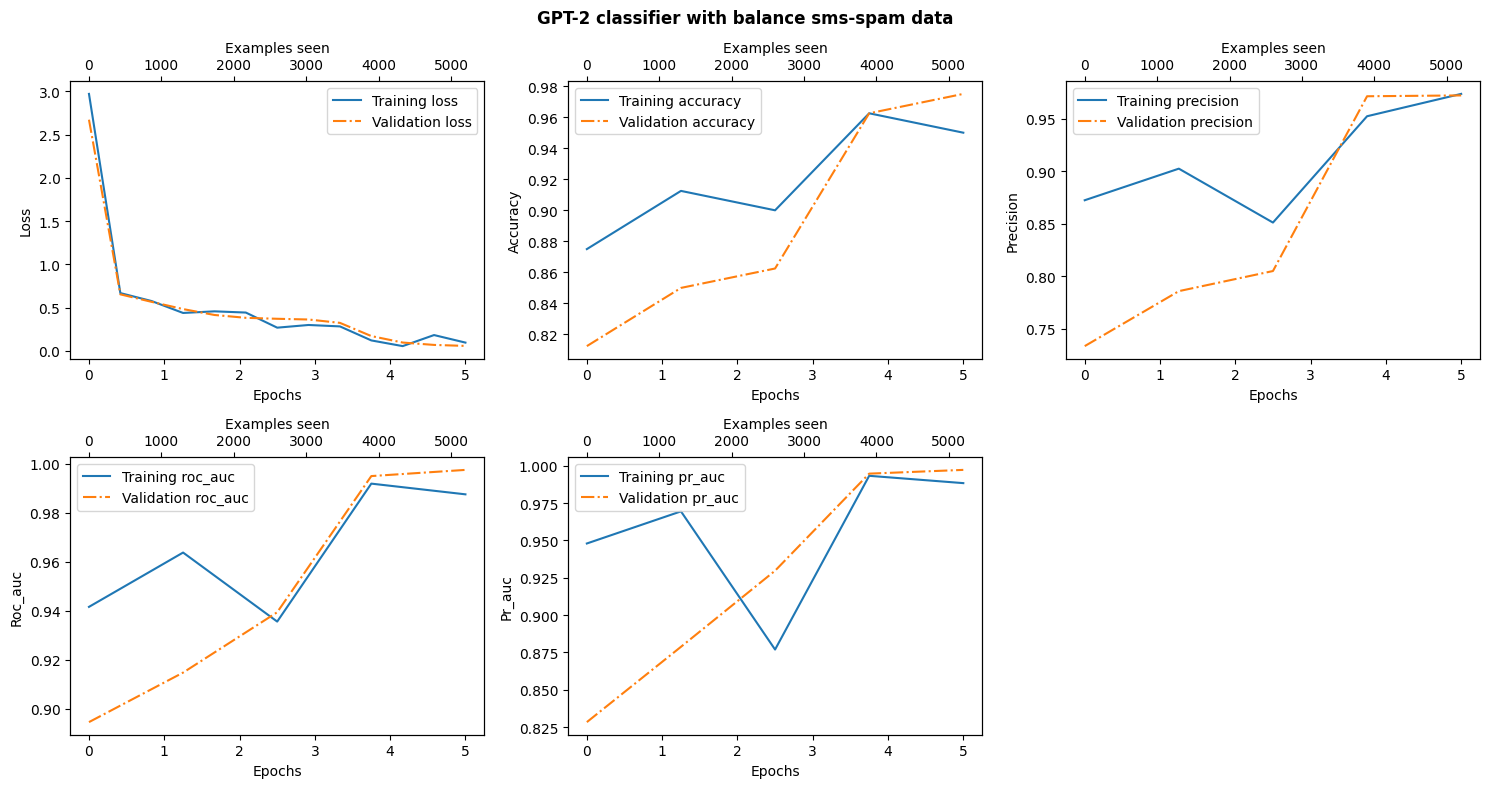

/content/gpt2-classifier/plots/sms-spam/metrics.png


In [11]:
from gpt2_classifier.utils import plot_results

fig_path = plot_results(
    num_epochs, *history,
    dataset="sms-spam",
    title="GPT-2 classifier with balance sms-spam data"
    )

print(fig_path)

---

## **Final Metric Evaluation Across Datasets**

As a final step in our evaluation pipeline, we compute comprehensive classification metrics across the training, validation, and test splits. Aggregating performance over all dataset mini-batches provides a statistically robust, out-of-sample assessment of our fine-tuned model's generalization capability.

In [12]:
from gpt2_classifier.evaluate import calc_classification_metrics_loader

train_metrics = calc_classification_metrics_loader(train_loader, model, device, num_batches=20)
val_metrics = calc_classification_metrics_loader(val_loader, model, device, num_batches=20)
test_metrics = calc_classification_metrics_loader(test_loader, model, device, num_batches=20)

print("Training metrics:")
print(
    f"Accuracy: {train_metrics.accuracy:.3f} | Precision: {train_metrics.precision:.3f} | ROC-AUC: {train_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {train_metrics.pr_auc:.3f}\n"
)

print("Validation metrics:")
print(
    f"Accuracy: {val_metrics.accuracy:.3f} | Precision: {val_metrics.precision:.3f} | ROC-AUC: {val_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {val_metrics.pr_auc:.3f}\n"
)

print("Test metrics:")
print(
    f"Accuracy: {test_metrics.accuracy:.3f} | Precision: {test_metrics.precision:.3f} | ROC-AUC: {test_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {test_metrics.pr_auc:.3f}\n"
)

Training metrics:
Accuracy: 0.956 | Precision: 0.955 | ROC-AUC: 0.991, |PR-AUC: 0.991

Validation metrics:
Accuracy: 0.987 | Precision: 0.986 | ROC-AUC: 0.999, |PR-AUC: 0.999

Test metrics:
Accuracy: 0.950 | Precision: 0.938 | ROC-AUC: 0.994, |PR-AUC: 0.994



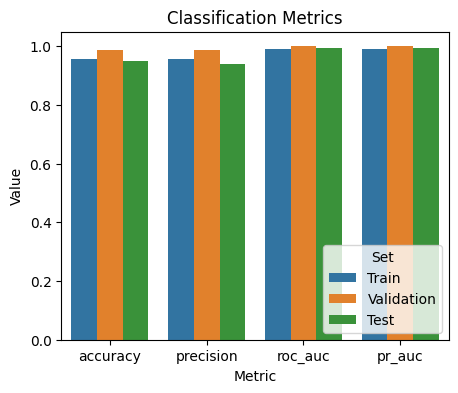

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Combine all metrics for Train, Validation, and Test sets in one dataframe
metrics_df = pd.DataFrame(
    {
        'Train': dict(train_metrics),
        'Validation': dict(val_metrics),
        'Test': dict(test_metrics),
    },
    index=pd.Index(['accuracy', 'precision', 'roc_auc', 'pr_auc'], name='Metric')
).reset_index()

# Pivot dataframe suitable for plotting
metrics_df_long = pd.melt(
    metrics_df, id_vars=['Metric'], value_vars=['Train', 'Validation', 'Test'], var_name='Set', value_name='Value')

fig, ax = plt.subplots(figsize=(5,4))

sns.barplot(ax=ax, data=metrics_df_long, x='Metric', y='Value', hue='Set')
ax.set_title("Classification Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.legend(title="Set", loc="lower right")
plt.show()

fig_dir  = paths.PLOTS_DIR / spec.name
if not fig_dir.exists():
    fig_dir.mkdir(parents=True)
fig.savefig(fig_dir / "model_metrics.png", dpi=300, bbox_inches='tight');

---

## **Inference: Out-of-Sample Predictions**

To verify that our classification head yields well-calibrated class probabilities, we perform an inference pass on two unseen samples: a representative spam text and a clean, non-spam baseline message. Executing this sanity check confirms that the model's decision boundary generalizes to qualitative inputs outside the validation split.

In [18]:
from gpt2_classifier.inference import classify_text

text_2 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_text(
    text_2, model, tokenizer, device, max_length=120
))

spam


In [19]:
from gpt2_classifier.inference import classify_text

text_3 = (
    "Hey Smith, how are you doing? Let's catch up sometime!"
)

print(classify_text(
    text_3, model, tokenizer, device, max_length=120
))

ham


We can see that the model made correct predictions on both messages.

---

## **Finetuning the Model With the Original Imbalanced Data**

In this section, we construct a dataset reflecting the target domain’s native, imbalanced class distribution by setting balance_labels=False in the prepare_dataset function. To overwrite the previously cached balanced artifacts, we pass force=True to re-execute the ingestion pipeline.

Following dataset generation, we instantiate fresh data loaders and fine-tune our classification model using the exact optimization pipeline applied to the balanced baseline.

In [20]:
path = prepare_dataset(spec, force=True, balance_labels=False, dataset_split=(0.7, 0.1, 0.2))
print("File path:", path)

File downloaded and saved as /content/gpt2-classifier/data/sms-spam/SMSSpamCollection
File path: /content/gpt2-classifier/data/sms-spam


In [21]:
train_loader, val_loader, test_loader = create_data_loaders(spec.name, batch_size=8)

for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Input batch dimensions: torch.Size([8, 257])
Label batch dimensions torch.Size([8])
487 training batches
70 validation batches
140 test batches


In [22]:
state_dict = download_and_load_gpt2(model_url, model_destination)
model = GPTModel(model_config)
load_weights_into_gpt(model, state_dict)

print(model)

The model already exists and is up-to-date: /content/gpt2-classifier/models/gpt2.safetensors
GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): 

In [23]:
# Swap teh GPT-2 head with a binary head
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(in_features=model_config['emb_dim'], out_features=num_classes)


# Turn off all trainable parameters
for param in model.parameters():
    param.requires_grad = False

# Turn on last layer of transformer block
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

# Turn on final LayerNorm
for param in model.final_norm.parameters():
    param.requires_grad = True

In [24]:
device = get_device()
model.to(device)

start_time = time.time()

torch.manual_seed(123)
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
optim_groups = get_adam_param_groups(model, weight_decay=0.1)
optimizer = torch.optim.AdamW(optim_groups, lr=5e-5)

num_epochs = 5

history = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=10,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 4.579, Val loss 3.965
Ep 1 (Step 000050): Train loss 0.500, Val loss 0.390
Ep 1 (Step 000100): Train loss 0.348, Val loss 0.335
Ep 1 (Step 000150): Train loss 0.338, Val loss 0.315
Ep 1 (Step 000200): Train loss 0.356, Val loss 0.311
Ep 1 (Step 000250): Train loss 0.207, Val loss 0.272
Ep 1 (Step 000300): Train loss 0.314, Val loss 0.261
Ep 1 (Step 000350): Train loss 0.314, Val loss 0.235
Ep 1 (Step 000400): Train loss 0.299, Val loss 0.226
Ep 1 (Step 000450): Train loss 0.221, Val loss 0.231
Training accuracy: 88.75% | Validation accuracy: 95.00%
Train precision: 0.500, ROC-AUC: 0.909, PR-AUC: 0.496 | Val precision: 0.909, ROC-AUC: 0.979, PR-AUC: 0.916
Ep 2 (Step 000500): Train loss 0.333, Val loss 0.172
Ep 2 (Step 000550): Train loss 0.153, Val loss 0.081
Ep 2 (Step 000600): Train loss 0.059, Val loss 0.073
Ep 2 (Step 000650): Train loss 0.142, Val loss 0.066
Ep 2 (Step 000700): Train loss 0.145, Val loss 0.064
Ep 2 (Step 000750): Train loss 0.145, Val

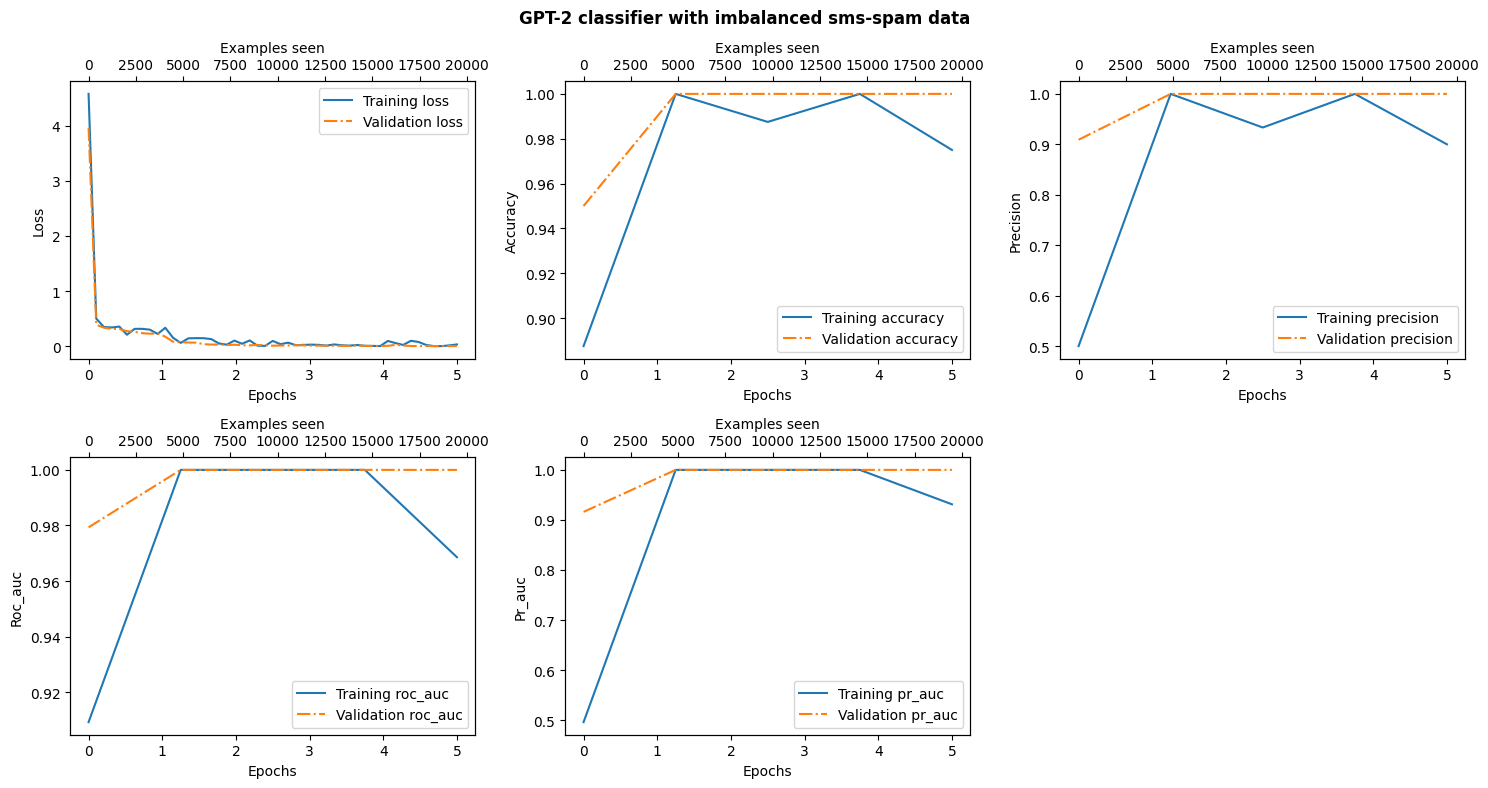

/content/gpt2-classifier/plots/sms-spam/metrics.png


In [25]:
fig_path = plot_results(
    num_epochs, *history,
    dataset="sms-spam",
    title="GPT-2 classifier with imbalanced sms-spam data"
    )

print(fig_path)

In [26]:
train_metrics = calc_classification_metrics_loader(train_loader, model, device, num_batches=100)
val_metrics = calc_classification_metrics_loader(val_loader, model, device, num_batches=100)
test_metrics = calc_classification_metrics_loader(test_loader, model, device, num_batches=100)

print("Training metrics:")
print(
    f"Accuracy: {train_metrics.accuracy:.3f} | Precision: {train_metrics.precision:.3f} | ROC-AUC: {train_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {train_metrics.pr_auc:.3f}\n"
)

print("Validation metrics:")
print(
    f"Accuracy: {val_metrics.accuracy:.3f} | Precision: {val_metrics.precision:.3f} | ROC-AUC: {val_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {val_metrics.pr_auc:.3f}\n"
)

print("Test metrics:")
print(
    f"Accuracy: {test_metrics.accuracy:.3f} | Precision: {test_metrics.precision:.3f} | ROC-AUC: {test_metrics.roc_auc:.3f}, |"
    f"PR-AUC: {test_metrics.pr_auc:.3f}\n"
)

Training metrics:
Accuracy: 0.991 | Precision: 0.954 | ROC-AUC: 0.994, |PR-AUC: 0.991

Validation metrics:
Accuracy: 0.995 | Precision: 0.986 | ROC-AUC: 0.996, |PR-AUC: 0.989

Test metrics:
Accuracy: 0.986 | Precision: 0.928 | ROC-AUC: 0.997, |PR-AUC: 0.987



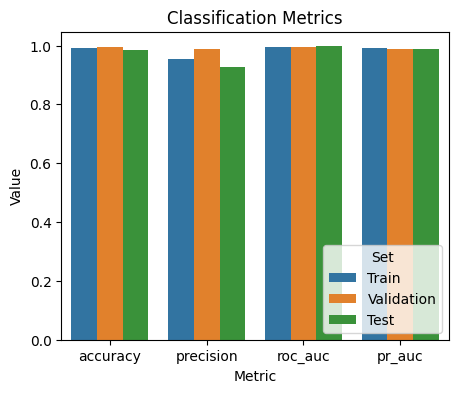

In [ ]:
# Combine all metrics for Train, Validation, and Test sets in one dataframe
metrics_df = pd.DataFrame(
    {
        'Train': dict(train_metrics),
        'Validation': dict(val_metrics),
        'Test': dict(test_metrics),
    },
    index=pd.Index(['accuracy', 'precision', 'roc_auc', 'pr_auc'], name='Metric')
).reset_index()

# Pivot dataframe suitable for plotting
metrics_df_long = pd.melt(
    metrics_df, id_vars=['Metric'], value_vars=['Train', 'Validation', 'Test'], var_name='Set', value_name='Value')

fig, ax = plt.subplots(figsize=(5,4))

sns.barplot(ax=ax, data=metrics_df_long, x='Metric', y='Value', hue='Set')
ax.set_title("Classification Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.legend(title="Set", loc="lower right")
plt.show()
fig_dir  = paths.PLOTS_DIR / spec.name
if not fig_dir.exists():
    fig_dir.mkdir(parents=True)
fig.savefig(fig_dir / "model_metrics.png", dpi=300, bbox_inches='tight');